# Sigmoid saturation demand

Closed-form shape (no data) for intuition, then synthetic `shape="sigmoid"` data. Compare **`SigmoidSaturationDemandModel`** to misspecified **`LogLogDemandModel`**.

From the repository root:

```bash
uv sync
```

MCMC settings in these notebooks use small `draws` / `tune` / `chains` for quick runs. Increase them for production-quality inference.


## Mean quantity vs price (analytical)

Same softplus form as the package, with a **fixed** center price for intuition.

In the fitted model, the center is **learned** as `log_price_center_sku` (prior mean = per-SKU median log-price from training; default `sigma=0.5`). Elasticity at that center equals `elasticity_sku`.


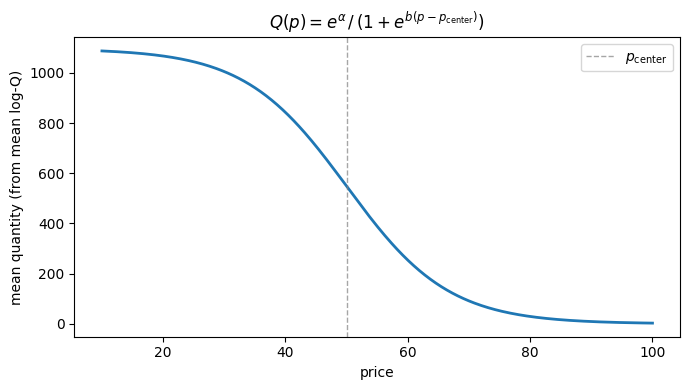

In [5]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 7.0
epsilon = -3.0
p_center = 50.0  # fixed here; fitted models learn price_center_sku

b = -2.0 * epsilon / p_center
p = np.linspace(10.0, 100.0, 400)
z = b * (p - p_center)
q_mean = np.exp(alpha) / (1.0 + np.exp(z))

plt.figure(figsize=(7, 4))
plt.plot(p, q_mean, color="C0", lw=2)
plt.axvline(
    p_center, color="gray", ls="--", lw=1, alpha=0.7, label=r"$p_{\mathrm{center}}$"
)
plt.xlabel("price")
plt.ylabel("mean quantity (from mean log-Q)")
plt.title(r"$Q(p)=e^{\alpha}\,/\,(1+e^{b(p-p_{\mathrm{center}})})$")
plt.legend()
plt.tight_layout()
plt.show()

## Fitted models on sigmoid DGP


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [log_price_center_sku, alpha_sku, elasticity_sku, sigma, beta_control]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, sigma, beta_control]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 1 seconds.


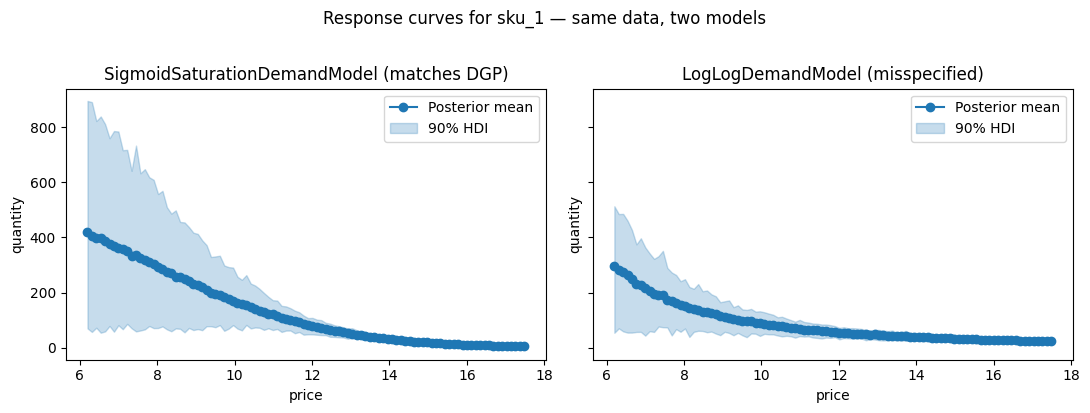

In [6]:
import warnings

warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np

from pypricing import (
    LogLogDemandModel,
    SigmoidSaturationDemandModel,
    generate_mock_data,
)


def controls_for_sku(df, model, sku):
    if not model.control_names_:
        return None
    sub = df[df[model.sku_col] == sku]
    return {c: float(sub[c].median()) for c in model.control_names_}


n_periods, n_skus, seed = 14, 4, 123

df_sig = generate_mock_data(
    n_periods=n_periods,
    n_skus=n_skus,
    n_controls=1,
    random_state=seed,
    shape="sigmoid",
)

fit_kw = dict(
    draws=120,
    tune=120,
    chains=2,
    random_seed=0,
    progressbar=False,
    compute_convergence_checks=False,
)

model_sig = SigmoidSaturationDemandModel()
model_sig.fit(df_sig, **fit_kw)

model_ll = LogLogDemandModel()
model_ll.fit(df_sig, **fit_kw)

sku0 = model_sig.sku_levels_[0]
lo = (
    float(df_sig.loc[df_sig[model_sig.sku_col] == sku0, model_sig.price_col].min())
    * 0.5
)
hi = (
    float(df_sig.loc[df_sig[model_sig.sku_col] == sku0, model_sig.price_col].max())
    * 1.2
)
price_grid = np.linspace(lo, hi, 100)
ctrl = controls_for_sku(df_sig, model_sig, sku0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
model_sig.plot_response_curve(
    sku=sku0,
    price_grid=price_grid,
    controls=ctrl,
    hdi_prob=0.9,
    ax=axes[0],
)
axes[0].set_title("SigmoidSaturationDemandModel (matches DGP)")

model_ll.plot_response_curve(
    sku=sku0,
    price_grid=price_grid,
    controls=ctrl,
    hdi_prob=0.9,
    ax=axes[1],
)
axes[1].set_title("LogLogDemandModel (misspecified)")

fig.suptitle(f"Response curves for {sku0} — same data, two models", y=1.02)
plt.tight_layout()
plt.show()

### Local elasticity along price

Pointwise **dμ / d log p** on the mean log-quantity path (same definition as in `plot_local_elasticity_vs_price`). On a **log–log** surface this is **constant** in price; on the **sigmoid** parameterization it generally **varies**. Below: same grid and controls as the response curves above.


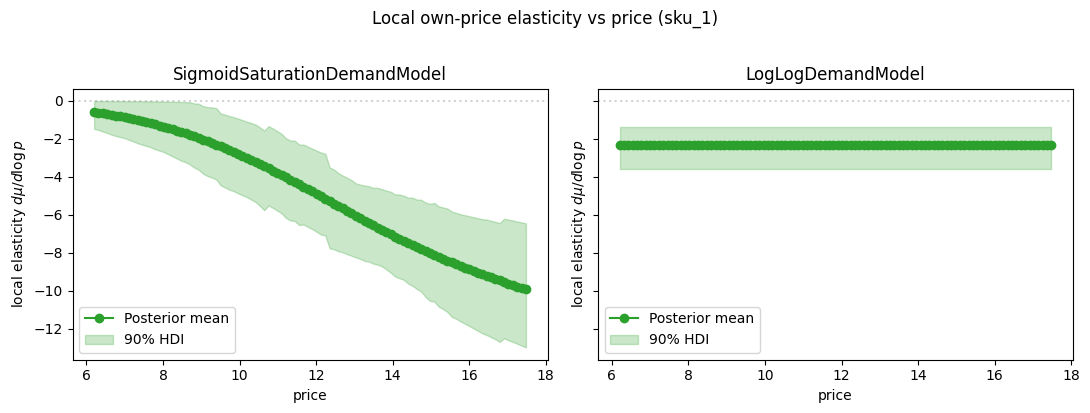

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
model_sig.plot_local_elasticity_vs_price(
    sku=sku0,
    price_grid=price_grid,
    controls=ctrl,
    hdi_prob=0.9,
    ax=axes[0],
)
axes[0].set_title("SigmoidSaturationDemandModel")

model_ll.plot_local_elasticity_vs_price(
    sku=sku0,
    price_grid=price_grid,
    controls=ctrl,
    hdi_prob=0.9,
    ax=axes[1],
)
axes[1].set_title("LogLogDemandModel")

fig.suptitle(f"Local own-price elasticity vs price ({sku0})", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
tt_kw = dict(
    test_size=0.25,
    period_col="period",
    hdi_prob=0.9,
    draws=120,
    tune=120,
    chains=2,
    random_seed=seed,
    progressbar=False,
    compute_convergence_checks=False,
)
out_sig = SigmoidSaturationDemandModel().fit_train_test(df_sig, **tt_kw)
out_ll = LogLogDemandModel().fit_train_test(df_sig, **tt_kw)
print(
    "RMSE (quantity, test):",
    out_sig["rmse"],
    "(sigmoid)",
    "|",
    out_ll["rmse"],
    "(log-log)",
)
print("HDI coverage:", out_sig["hdi_coverage"], "|", out_ll["hdi_coverage"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [log_price_center_sku, alpha_sku, elasticity_sku, sigma, beta_control]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_sku, elasticity_sku, sigma, beta_control]
Sampling 2 chains for 120 tune and 120 draw iterations (240 + 240 draws total) took 1 seconds.


RMSE (quantity, test): 26.40707048255227 (sigmoid) | 26.54486031963103 (log-log)
HDI coverage: 0.875 | 0.6875
